## 0. Setup: imports, reproducibility, output folders

In [102]:

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.feature_selection import SelectKBest, mutual_info_classif, f_classif, RFECV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

warnings.filterwarnings("ignore")


RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["savefig.bbox"] = "tight"

OUT_DIR = "outputs"
FIG_DIR = os.path.join(OUT_DIR, "figures")
TAB_DIR = os.path.join(OUT_DIR, "tables")
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TAB_DIR, exist_ok=True)

print("Setup complete. Figures ->", FIG_DIR, "| Tables ->", TAB_DIR)


Setup complete. Figures -> outputs\figures | Tables -> outputs\tables


## 1. Importing the dataset

The UCI Cleveland Heart Disease dataset (`processed_cleveland.data`) is a **headerless CSV** with 14 columns and missing values encoded as `"?"`. Column names follow the official UCI documentation (`heart-disease.names`).


In [104]:
DATA_PATH = "processed_cleveland.data"  

COLUMN_NAMES = [
    "age",       # age in years
    "sex",       # 1 = male, 0 = female
    "cp",        # chest pain type (1-4)
    "trestbps",  # resting blood pressure (mm Hg)
    "chol",      # serum cholesterol (mg/dl)
    "fbs",       # fasting blood sugar > 120 mg/dl (1 = true, 0 = false)
    "restecg",   # resting ECG results (0-2)
    "thalach",   # maximum heart rate achieved
    "exang",     # exercise-induced angina (1 = yes, 0 = no)
    "oldpeak",   # ST depression induced by exercise relative to rest
    "slope",     # slope of the peak exercise ST segment (1-3)
    "ca",        # number of major vessels (0-3) colored by fluoroscopy
    "thal",      # 3 = normal, 6 = fixed defect, 7 = reversible defect
    "target"     # diagnosis of heart disease (0 = absent, 1-4 = present, increasing severity)
]

df = pd.read_csv(DATA_PATH, header=None, names=COLUMN_NAMES, na_values="?")

print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()


Dataset loaded: 303 rows, 14 columns


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## 2. Inspecting and understanding the data

In [106]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


In [108]:
print("Shape:", df.shape)
print("\nColumn dtypes:\n", df.dtypes)
print("\nFirst 5 rows:")
df.head()


Shape: (303, 14)

Column dtypes:
 age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target        int64
dtype: object

First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [110]:
df.describe(include="all").T


,count,mean,std,min,25%,50%,75%,max
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.679868,0.467299,0.0,0.0,1.0,1.0,1.0
cp,303.0,3.158416,0.960126,1.0,3.0,3.0,4.0,4.0
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.990099,0.994971,0.0,0.0,1.0,2.0,2.0
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


## 3. Data-quality checks

### 3.1 Missing values


In [112]:
missing_counts = df.isna().sum()
missing_pct = (missing_counts / len(df) * 100).round(2)
missing_summary = pd.DataFrame({"missing_count": missing_counts, "missing_pct": missing_pct})
missing_summary = missing_summary[missing_summary["missing_count"] > 0]
print("Columns with missing values:")
missing_summary


Columns with missing values:


,missing_count,missing_pct
ca,4,1.32
thal,2,0.66


### 3.2 Duplicate rows

In [114]:
n_duplicates = df.duplicated().sum()
print(f"Number of fully duplicated rows: {n_duplicates}")
if n_duplicates > 0:
    display(df[df.duplicated(keep=False)].sort_values(by=list(df.columns)))


Number of fully duplicated rows: 0


### 3.3 Incorrect / unusual values


In [116]:
valid_ranges = {
    "sex":      [0, 1],
    "cp":       [1, 2, 3, 4],
    "fbs":      [0, 1],
    "restecg":  [0, 1, 2],
    "exang":    [0, 1],
    "slope":    [1, 2, 3],
    "ca":       [0, 1, 2, 3],
    "thal":     [3, 6, 7],
    "target":   [0, 1, 2, 3, 4],
}

print("Checking categorical variables against documented valid categories:\n")
for col, valid_vals in valid_ranges.items():
    observed = set(df[col].dropna().unique())
    unexpected = observed - set(valid_vals)
    status = "OK" if not unexpected else f"UNEXPECTED VALUES: {unexpected}"
    print(f"  {col:10s} -> observed {sorted(observed)} | {status}")

print("\nChecking continuous variables for implausible values (e.g. <= 0 where physiologically impossible):\n")
continuous_cols = ["age", "trestbps", "chol", "thalach", "oldpeak"]
print(df[continuous_cols].describe().T[["min", "max"]])


Checking categorical variables against documented valid categories:

  sex        -> observed [0.0, 1.0] | OK
  cp         -> observed [1.0, 2.0, 3.0, 4.0] | OK
  fbs        -> observed [0.0, 1.0] | OK
  restecg    -> observed [0.0, 1.0, 2.0] | OK
  exang      -> observed [0.0, 1.0] | OK
  slope      -> observed [1.0, 2.0, 3.0] | OK
  ca         -> observed [0.0, 1.0, 2.0, 3.0] | OK
  thal       -> observed [3.0, 6.0, 7.0] | OK
  target     -> observed [0, 1, 2, 3, 4] | OK

Checking continuous variables for implausible values (e.g. <= 0 where physiologically impossible):

            min    max
age        29.0   77.0
trestbps   94.0  200.0
chol      126.0  564.0
thalach    71.0  202.0
oldpeak     0.0    6.2


### 3.4 Data types

In [118]:
print(df.dtypes)
print("\nNote: several columns (sex, cp, fbs, restecg, exang, slope, ca, thal) are categorical/ordinal")
print("but are stored as float64 because of the '?' missing-value markers read by pandas.")
print("They will be explicitly cast after imputation in the preprocessing section.")


age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target        int64
dtype: object

Note: several columns (sex, cp, fbs, restecg, exang, slope, ca, thal) are categorical/ordinal
but are stored as float64 because of the '?' missing-value markers read by pandas.
They will be explicitly cast after imputation in the preprocessing section.


### 3.5 Class distribution (target variable)

In [120]:
print("Original multiclass target distribution (0 = no disease, 1-4 = increasing severity):")
print(df["target"].value_counts().sort_index())

df["target_binary"] = (df["target"] > 0).astype(int)

print("\nBinary target distribution (0 = no disease, 1 = disease present):")
print(df["target_binary"].value_counts())
print(df["target_binary"].value_counts(normalize=True).round(3) * 100, "%")


Original multiclass target distribution (0 = no disease, 1-4 = increasing severity):
target
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64

Binary target distribution (0 = no disease, 1 = disease present):
target_binary
0    164
1    139
Name: count, dtype: int64
target_binary
0    54.1
1    45.9
Name: proportion, dtype: float64 %


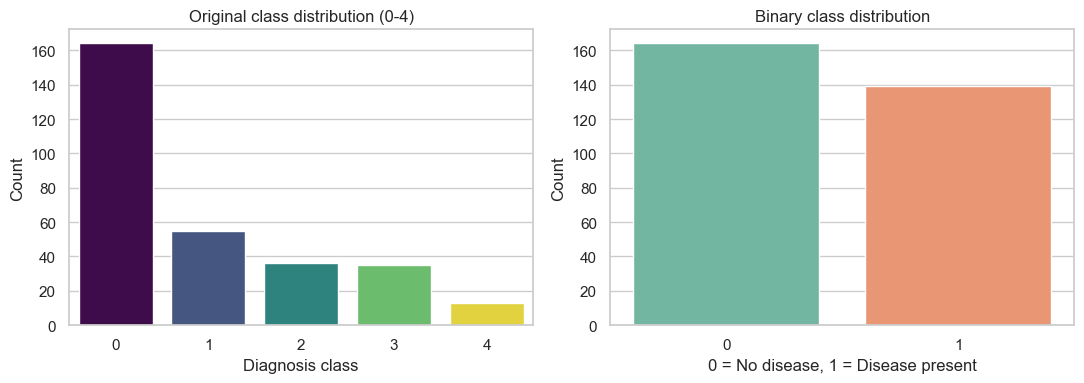

In [122]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.countplot(x="target", data=df, ax=axes[0], hue="target", palette="viridis", legend=False)
axes[0].set_title("Original class distribution (0-4)")
axes[0].set_xlabel("Diagnosis class")
axes[0].set_ylabel("Count")

sns.countplot(x="target_binary", data=df, ax=axes[1], hue="target_binary", palette="Set2", legend=False)
axes[1].set_title("Binary class distribution")
axes[1].set_xlabel("0 = No disease, 1 = Disease present")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "01_class_distribution.png"))
plt.show()


## 4. Exploratory Data Analysis (EDA)

### 4.1 Descriptive statistics (by class)


In [124]:
desc_by_class = df.groupby("target_binary")[continuous_cols].agg(["mean", "std", "median", "min", "max"]).round(2)
desc_by_class.to_csv(os.path.join(TAB_DIR, "table_descriptive_stats_by_class.csv"))
desc_by_class


age                          trestbps                       \
                mean   std median   min   max     mean    std median    min   
target_binary                                                                 
0              52.59  9.51   52.0  29.0  76.0   129.25  16.20  130.0   94.0   
1              56.63  7.94   58.0  35.0  77.0   134.57  18.77  130.0  100.0   

                      ... thalach                            oldpeak        \
                 max  ...    mean    std median   min    max    mean   std   
target_binary         ...                                                    
0              180.0  ...  158.38  19.20  161.0  96.0  202.0    0.59  0.78   
1              200.0  ...  139.26  22.59  142.0  71.0  195.0    1.57  1.30   

                                
              median  min  max  
target_binary                   
0                0.2  0.0  4.2  
1                1.4  0.0  6.2  

[2 rows x 25 columns]

### 4.2 Distributions of continuous variables

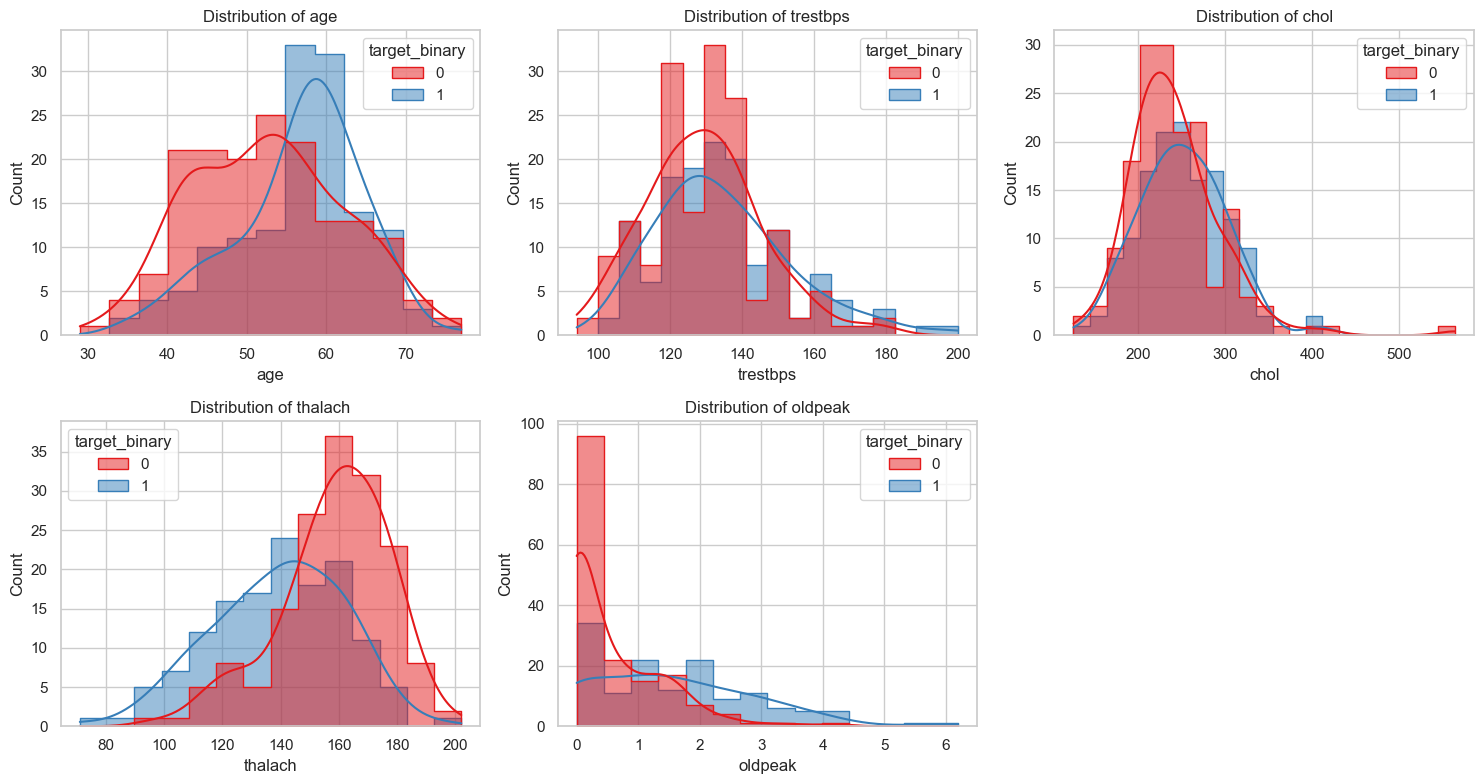

In [126]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(continuous_cols):
    sns.histplot(data=df, x=col, hue="target_binary", kde=True, ax=axes[i],
                 palette="Set1", alpha=0.5, element="step")
    axes[i].set_title(f"Distribution of {col}")

# hide the unused 6th subplot
axes[-1].axis("off")

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "02_continuous_distributions.png"))
plt.show()


### 4.3 Distributions of categorical variables

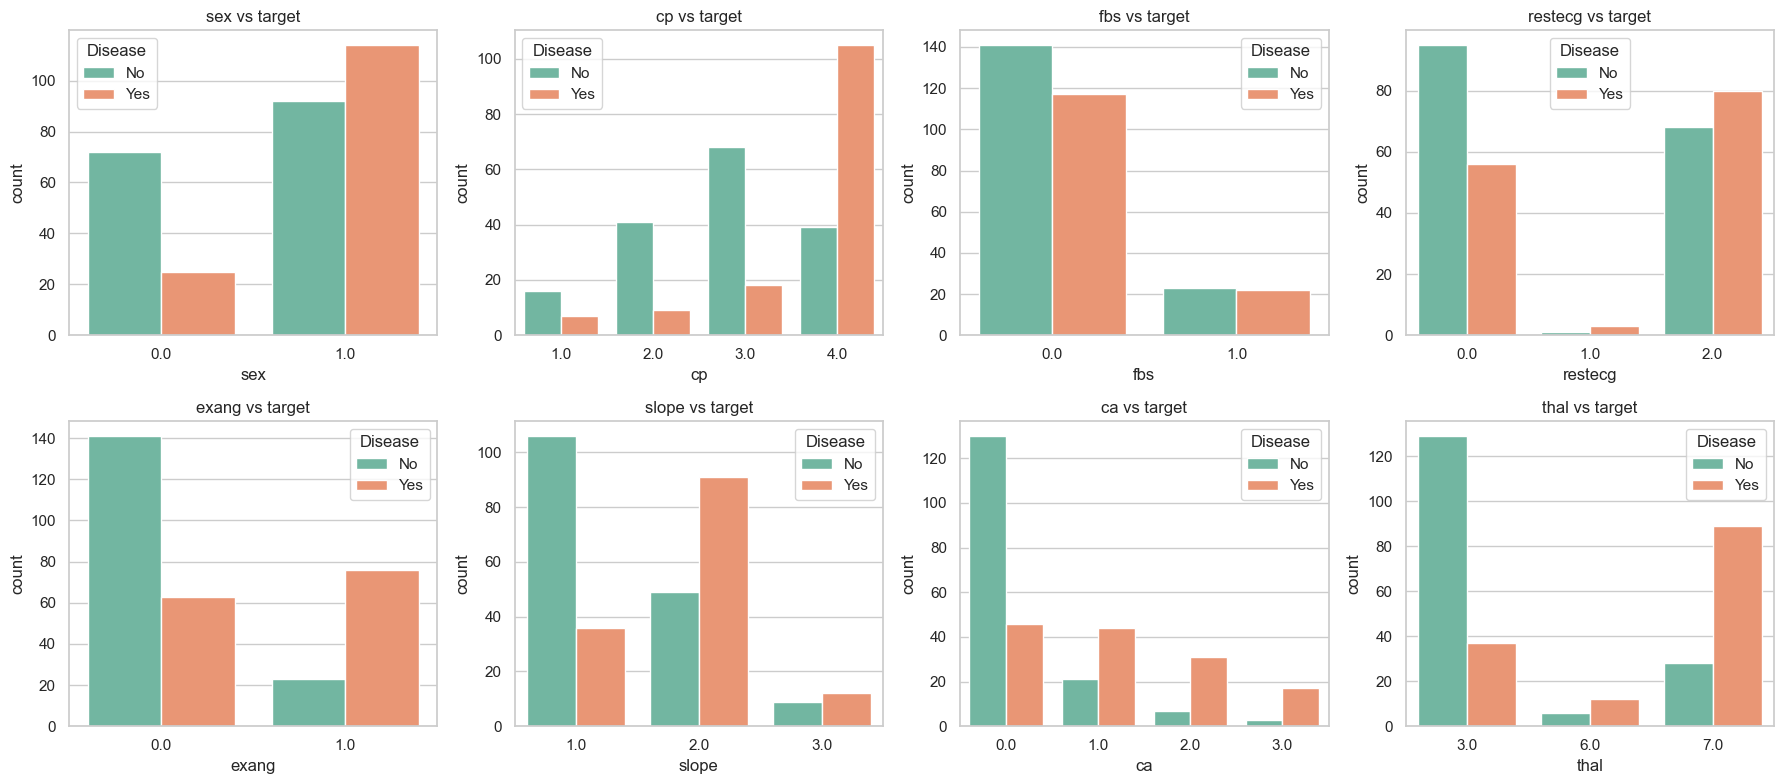

In [128]:
categorical_cols = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(data=df, x=col, hue="target_binary", ax=axes[i], palette="Set2")
    axes[i].set_title(f"{col} vs target")
    axes[i].legend(title="Disease", labels=["No", "Yes"])

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "03_categorical_distributions.png"))
plt.show()


### 4.4 Boxplots — continuous variables by class (outlier inspection)

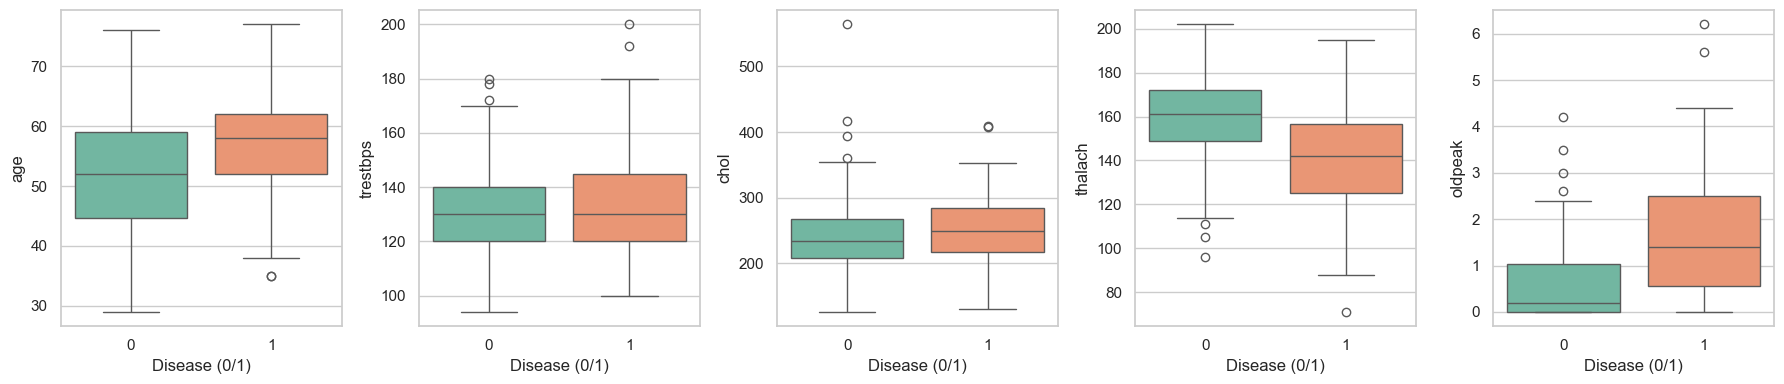

In [130]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for i, col in enumerate(continuous_cols):
    sns.boxplot(data=df, x="target_binary", y=col, ax=axes[i], hue="target_binary",
                palette="Set2", legend=False)
    axes[i].set_xlabel("Disease (0/1)")

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "04_boxplots_continuous.png"))
plt.show()


### 4.5 Correlation analysis


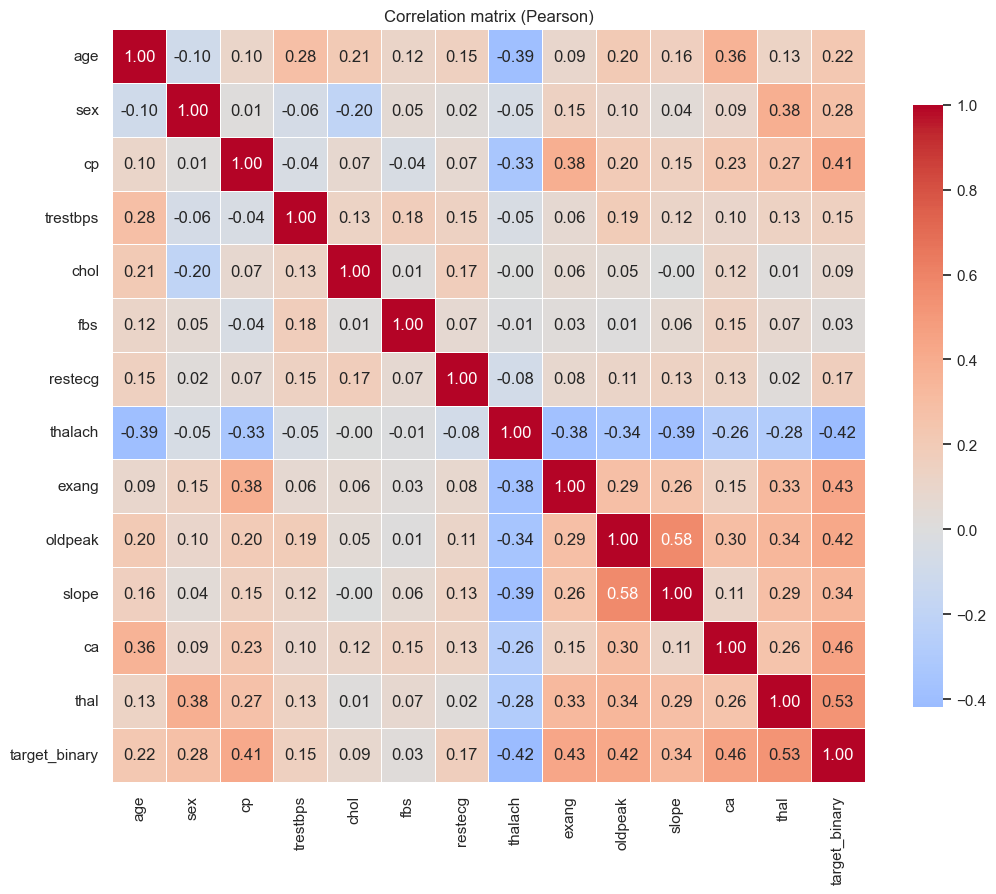

In [132]:
corr_cols = [c for c in df.columns if c not in ["target"]]  # keep target_binary, drop multiclass target
corr_matrix = df[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(11, 9))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Correlation matrix (Pearson)")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "05_correlation_heatmap.png"))
plt.show()

corr_matrix.to_csv(os.path.join(TAB_DIR, "table_correlation_matrix.csv"))


Features ranked by |correlation| with target_binary:

thal        0.526
ca          0.460
exang       0.432
oldpeak     0.425
thalach    -0.417
cp          0.414
slope       0.339
sex         0.277
age         0.223
restecg     0.169
trestbps    0.151
chol        0.085
fbs         0.025
Name: target_binary, dtype: float64


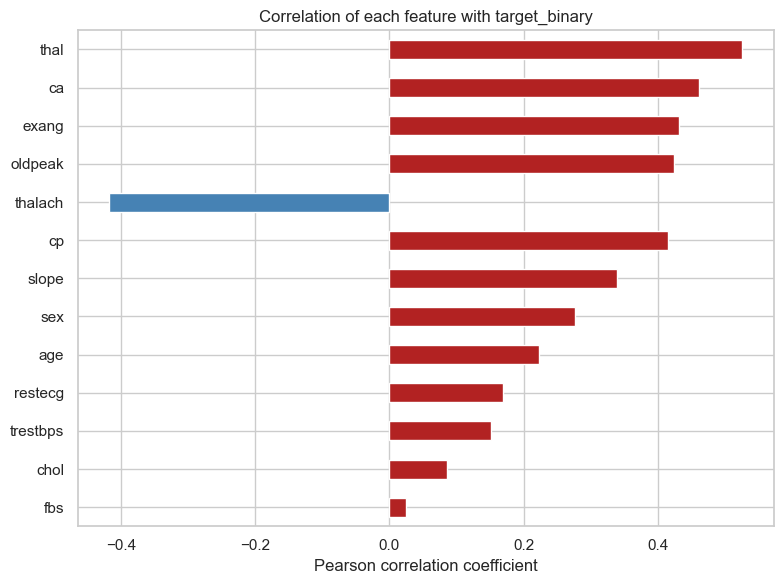

In [134]:
# Correlation of each feature with the binary target, sorted
target_corr = corr_matrix["target_binary"].drop("target_binary").sort_values(key=abs, ascending=False)
print("Features ranked by |correlation| with target_binary:\n")
print(target_corr.round(3))

plt.figure(figsize=(8, 6))
target_corr.plot(kind="barh", color=np.where(target_corr > 0, "firebrick", "steelblue"))
plt.title("Correlation of each feature with target_binary")
plt.xlabel("Pearson correlation coefficient")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "06_target_correlation_ranked.png"))
plt.show()


## 5. Data preprocessing

Steps applied, in order:
1. **Missing values** 
2. **Encoding** 
3. **Scaling** 


In [136]:

df_clean = df.copy()

for col in ["ca", "thal"]:
    mode_val = df_clean[col].mode()[0]
    n_missing = df_clean[col].isna().sum()
    df_clean[col] = df_clean[col].fillna(mode_val)
    print(f"Imputed {n_missing} missing value(s) in '{col}' with mode = {mode_val}")


categorical_int_cols = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]
df_clean[categorical_int_cols] = df_clean[categorical_int_cols].astype(int)

print("\nRemaining missing values after cleaning:", df_clean.isna().sum().sum())
df_clean.head()


Imputed 4 missing value(s) in 'ca' with mode = 0.0
Imputed 2 missing value(s) in 'thal' with mode = 3.0

Remaining missing values after cleaning: 0


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,target_binary
0,63.0,1,1,145.0,233.0,1,2,150.0,0,2.3,3,0,6,0,0
1,67.0,1,4,160.0,286.0,0,2,108.0,1,1.5,2,3,3,2,1
2,67.0,1,4,120.0,229.0,0,2,129.0,1,2.6,2,2,7,1,1
3,37.0,1,3,130.0,250.0,0,0,187.0,0,3.5,3,0,3,0,0
4,41.0,0,2,130.0,204.0,0,2,172.0,0,1.4,1,0,3,0,0


In [138]:

FEATURE_COLS = [c for c in df_clean.columns if c not in ["target", "target_binary"]]
X = df_clean[FEATURE_COLS].copy()
y = df_clean["target_binary"].copy()

print("Feature columns used for modelling:", FEATURE_COLS)
print("X shape:", X.shape, "| y shape:", y.shape)


Feature columns used for modelling: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
X shape: (303, 13) | y shape: (303,)


## 6. Train/test splitting


In [140]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print(f"Train set: {X_train.shape[0]} samples | Test set: {X_test.shape[0]} samples")
print("\nTrain class balance:\n", y_train.value_counts(normalize=True).round(3))
print("\nTest class balance:\n", y_test.value_counts(normalize=True).round(3))

# Scale continuous features (fit on train only, transform both)
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_test_scaled[continuous_cols] = scaler.transform(X_test[continuous_cols])

print("\nScaling applied to continuous columns:", continuous_cols)


Train set: 242 samples | Test set: 61 samples

Train class balance:
 target_binary
0    0.541
1    0.459
Name: proportion, dtype: float64

Test class balance:
 target_binary
0    0.541
1    0.459
Name: proportion, dtype: float64

Scaling applied to continuous columns: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']


## 7. Baseline models (full feature set)



In [142]:
def make_models():
    """Factory so we get fresh, identically-configured model instances each time."""
    return {
        "Logistic Regression": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
        "Random Forest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
        "SVM (RBF kernel)": SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE),
    }

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


In [144]:
def evaluate_model(model, X_tr, y_tr, X_te, y_te, model_name, feature_set_name):
    """Fit a model and compute the full set of evaluation metrics used in this analysis."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1] if hasattr(model, "predict_proba") else model.decision_function(X_te)

    tn, fp, fn, tp = confusion_matrix(y_te, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan

    results = {
        "Model": model_name,
        "Feature Set": feature_set_name,
        "Accuracy": accuracy_score(y_te, y_pred),
        "Precision": precision_score(y_te, y_pred),
        "Recall (Sensitivity)": recall_score(y_te, y_pred),
        "Specificity": specificity,
        "F1-score": f1_score(y_te, y_pred),
        "ROC-AUC": roc_auc_score(y_te, y_proba),
    }
    return results, model, y_pred, y_proba

baseline_results = []
baseline_models_fitted = {}
baseline_preds = {}

for name, mdl in make_models().items():
    res, fitted, y_pred, y_proba = evaluate_model(
        mdl, X_train_scaled, y_train, X_test_scaled, y_test, name, "Full feature set"
    )
    baseline_results.append(res)
    baseline_models_fitted[name] = fitted
    baseline_preds[name] = (y_pred, y_proba)

baseline_results_df = pd.DataFrame(baseline_results).set_index("Model")
baseline_results_df.round(4)


,Feature Set,Accuracy,Precision,Recall (Sensitivity),Specificity,F1-score,ROC-AUC
Model,,,,,,,
Logistic Regression,Full feature set,0.8689,0.8125,0.9286,0.8182,0.8667,0.9513
Random Forest,Full feature set,0.9180,0.8710,0.9643,0.8788,0.9153,0.9578
SVM (RBF kernel),Full feature set,0.8197,0.7742,0.8571,0.7879,0.8136,0.9199


In [146]:

print("5-fold stratified cross-validation accuracy (training set, full feature set):\n")
for name, mdl in make_models().items():
    scores = cross_val_score(mdl, X_train_scaled, y_train, cv=cv_strategy, scoring="accuracy")
    print(f"  {name:22s}: mean = {scores.mean():.4f}  (+/- {scores.std():.4f})")


5-fold stratified cross-validation accuracy (training set, full feature set):

  Logistic Regression   : mean = 0.8305  (+/- 0.0304)
  Random Forest         : mean = 0.8139  (+/- 0.0202)
  SVM (RBF kernel)      : mean = 0.8059  (+/- 0.0242)


## 8. Feature selection

### Justification for the chosen techniques

To make the comparison robust, **three complementary categories** of feature selection are applied
and cross-checked, following the standard taxonomy in the feature selection literature (Guyon &
Elisseeff, 2003; Chandrashekar & Sahin, 2014):

| Category | Technique used | Rationale |
|---|---|---|
| **Filter** | Mutual Information (`mutual_info_classif`) and ANOVA F-test (`f_classif`) via `SelectKBest` | Model-agnostic, computationally cheap, captures both linear (F-test) and non-linear (MI) dependence between each feature and the target — appropriate as a first-pass screen before modelling. |
| **Wrapper** | Recursive Feature Elimination with cross-validation (`RFECV`), using Logistic Regression as the estimator | Evaluates feature subsets using actual downstream model performance (5-fold CV accuracy), directly optimising for the classification task rather than a proxy statistic. |
| **Embedded** | Random Forest feature importance (Gini importance) | Feature selection is a by-product of model training itself, capturing non-linear interactions the filter methods miss, and is a widely reported approach in Cleveland-dataset studies. |



### 8.1 Filter method 1 — ANOVA F-test

In [147]:
f_scores, f_pvalues = f_classif(X_train_scaled, y_train)
anova_df = pd.DataFrame({
    "Feature": FEATURE_COLS,
    "F-score": f_scores,
    "p-value": f_pvalues
}).sort_values("F-score", ascending=False).reset_index(drop=True)

anova_df.to_csv(os.path.join(TAB_DIR, "table_anova_f_scores.csv"), index=False)
anova_df.round(4)


,Feature,F-score,p-value
0,thal,101.0324,0.0000
1,ca,60.2524,0.0000
2,exang,51.4869,0.0000
3,thalach,48.3471,0.0000
4,cp,45.8833,0.0000
5,oldpeak,43.6150,0.0000
6,slope,28.0231,0.0000
7,sex,25.2154,0.0000
8,age,11.0352,0.0010
9,restecg,6.3348,0.0125


### 8.2 Filter method 2 — Mutual Information

In [150]:
mi_scores = mutual_info_classif(X_train_scaled, y_train, random_state=RANDOM_STATE)
mi_df = pd.DataFrame({
    "Feature": FEATURE_COLS,
    "Mutual Information": mi_scores
}).sort_values("Mutual Information", ascending=False).reset_index(drop=True)

mi_df.to_csv(os.path.join(TAB_DIR, "table_mutual_information.csv"), index=False)
mi_df.round(4)


,Feature,Mutual Information
0,thal,0.1835
1,ca,0.1505
2,cp,0.1338
3,slope,0.1035
4,thalach,0.0907
5,oldpeak,0.0790
6,exang,0.0660
7,chol,0.0655
8,sex,0.0236
9,fbs,0.0201


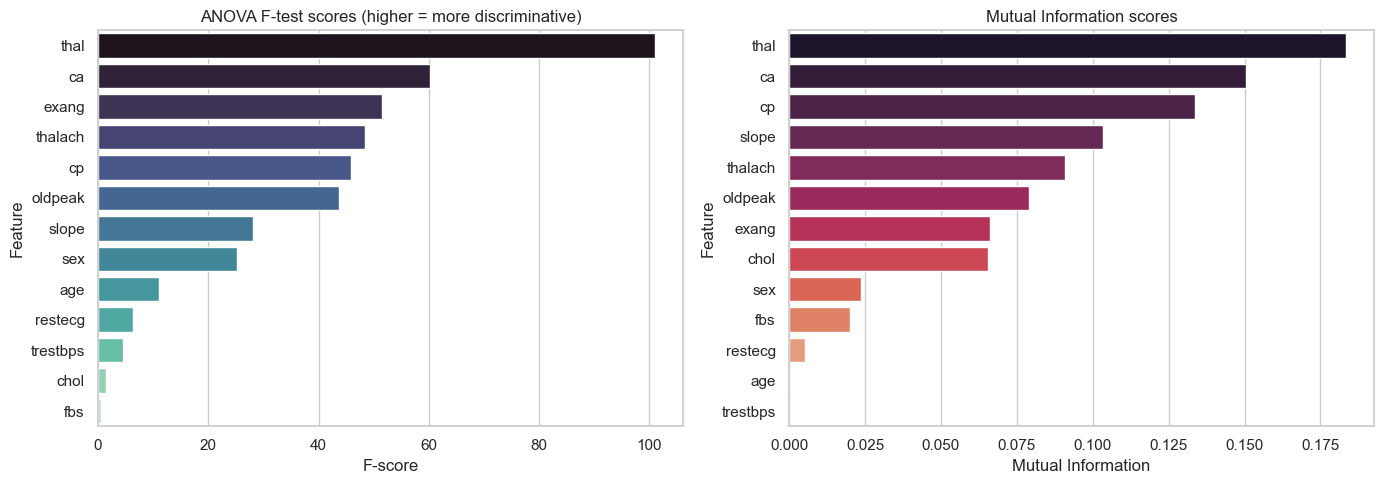

In [152]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=anova_df, y="Feature", x="F-score", ax=axes[0], hue="Feature",
            palette="mako", legend=False)
axes[0].set_title("ANOVA F-test scores (higher = more discriminative)")

sns.barplot(data=mi_df, y="Feature", x="Mutual Information", ax=axes[1], hue="Feature",
            palette="rocket", legend=False)
axes[1].set_title("Mutual Information scores")

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "07_filter_method_scores.png"))
plt.show()


### 8.3 Embedded method — Random Forest feature importance

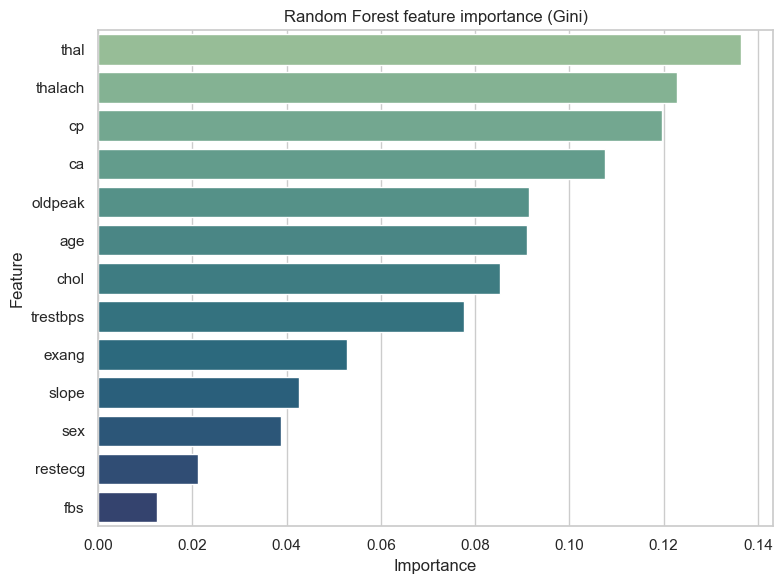

,Feature,Importance
0,thal,0.1364
1,thalach,0.1229
2,cp,0.1198
3,ca,0.1076
4,oldpeak,0.0914
5,age,0.0911
6,chol,0.0853
7,trestbps,0.0776
8,exang,0.0528
9,slope,0.0427


In [154]:
rf_for_importance = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)
rf_for_importance.fit(X_train_scaled, y_train)

rf_importance_df = pd.DataFrame({
    "Feature": FEATURE_COLS,
    "Importance": rf_for_importance.feature_importances_
}).sort_values("Importance", ascending=False).reset_index(drop=True)

rf_importance_df.to_csv(os.path.join(TAB_DIR, "table_rf_feature_importance.csv"), index=False)

plt.figure(figsize=(8, 6))
sns.barplot(data=rf_importance_df, y="Feature", x="Importance", hue="Feature",
            palette="crest", legend=False)
plt.title("Random Forest feature importance (Gini)")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "08_rf_feature_importance.png"))
plt.show()

rf_importance_df.round(4)


### 8.4 Wrapper method — Recursive Feature Elimination with Cross-Validation (RFECV)

RFECV recursively removes the weakest feature(s) and evaluates the remaining subset via cross-validated
accuracy, automatically selecting the subset size that maximises CV performance — this avoids having to
arbitrarily pre-specify "top-k".


Optimal number of features selected by RFECV: 9
Selected features: ['sex', 'cp', 'trestbps', 'fbs', 'thalach', 'exang', 'slope', 'ca', 'thal']


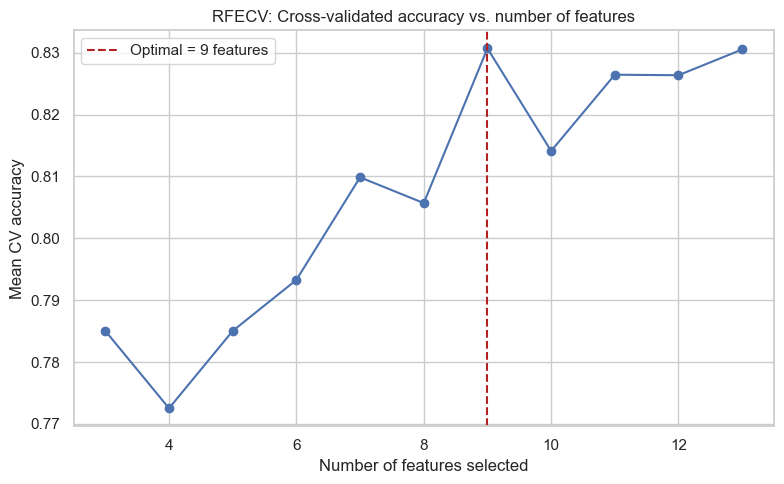

In [156]:
rfecv_estimator = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)

rfecv = RFECV(
    estimator=rfecv_estimator,
    step=1,
    cv=cv_strategy,
    scoring="accuracy",
    min_features_to_select=3,
)
rfecv.fit(X_train_scaled, y_train)

selected_features_rfecv = list(X_train_scaled.columns[rfecv.support_])
print(f"Optimal number of features selected by RFECV: {rfecv.n_features_}")
print(f"Selected features: {selected_features_rfecv}")


mean_scores = rfecv.cv_results_["mean_test_score"]

if "n_features" in rfecv.cv_results_:
    n_features_range = rfecv.cv_results_["n_features"]
else:
    n_features_range = np.arange(
        rfecv.min_features_to_select,
        rfecv.min_features_to_select + len(mean_scores)
    )

plt.figure(figsize=(8, 5))
plt.plot(n_features_range, mean_scores, marker="o")
plt.axvline(rfecv.n_features_, color="firebrick", linestyle="--",
            label=f"Optimal = {rfecv.n_features_} features")
plt.xlabel("Number of features selected")
plt.ylabel("Mean CV accuracy")
plt.title("RFECV: Cross-validated accuracy vs. number of features")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "09_rfecv_curve.png"))
plt.show()

### 8.5 Triangulating the three approaches


In [158]:
top_k = rfecv.n_features_

top_anova = set(anova_df.head(top_k)["Feature"])
top_mi = set(mi_df.head(top_k)["Feature"])
top_rf = set(rf_importance_df.head(top_k)["Feature"])
top_rfecv = set(selected_features_rfecv)

comparison_df = pd.DataFrame({
    "Feature": FEATURE_COLS,
    "In ANOVA top-k": [f in top_anova for f in FEATURE_COLS],
    "In MI top-k": [f in top_mi for f in FEATURE_COLS],
    "In RF-importance top-k": [f in top_rf for f in FEATURE_COLS],
    "Selected by RFECV (final)": [f in top_rfecv for f in FEATURE_COLS],
})
comparison_df["Agreement count"] = comparison_df[[
    "In ANOVA top-k", "In MI top-k", "In RF-importance top-k", "Selected by RFECV (final)"
]].sum(axis=1)
comparison_df = comparison_df.sort_values("Agreement count", ascending=False).reset_index(drop=True)

comparison_df.to_csv(os.path.join(TAB_DIR, "table_feature_selection_triangulation.csv"), index=False)
comparison_df


,Feature,In ANOVA top-k,In MI top-k,In RF-importance top-k,Selected by RFECV (final),Agreement count
0,cp,True,True,True,True,4
1,thalach,True,True,True,True,4
2,exang,True,True,True,True,4
3,ca,True,True,True,True,4
4,thal,True,True,True,True,4
5,sex,True,True,False,True,3
6,oldpeak,True,True,True,False,3
7,slope,True,True,False,True,3
8,age,True,False,True,False,2
9,trestbps,False,False,True,True,2


In [160]:

SELECTED_FEATURES = selected_features_rfecv
print(f"FINAL SELECTED FEATURE SET (via RFECV, n={len(SELECTED_FEATURES)}):")
print(SELECTED_FEATURES)

X_train_selected = X_train_scaled[SELECTED_FEATURES]
X_test_selected = X_test_scaled[SELECTED_FEATURES]


FINAL SELECTED FEATURE SET (via RFECV, n=9):
['sex', 'cp', 'trestbps', 'fbs', 'thalach', 'exang', 'slope', 'ca', 'thal']


## 9. Models using the selected feature subset

The same three classifiers, with the same hyperparameters as the baseline, are retrained using
**only** `SELECTED_FEATURES`. 


In [162]:
selected_results = []
selected_models_fitted = {}
selected_preds = {}

for name, mdl in make_models().items():
    res, fitted, y_pred, y_proba = evaluate_model(
        mdl, X_train_selected, y_train, X_test_selected, y_test, name, "Selected features"
    )
    selected_results.append(res)
    selected_models_fitted[name] = fitted
    selected_preds[name] = (y_pred, y_proba)

selected_results_df = pd.DataFrame(selected_results).set_index("Model")
selected_results_df.round(4)


,Feature Set,Accuracy,Precision,Recall (Sensitivity),Specificity,F1-score,ROC-AUC
Model,,,,,,,
Logistic Regression,Selected features,0.8852,0.8387,0.9286,0.8485,0.8814,0.9416
Random Forest,Selected features,0.8525,0.8065,0.8929,0.8182,0.8475,0.9394
SVM (RBF kernel),Selected features,0.8033,0.7667,0.8214,0.7879,0.7931,0.9150


In [164]:
print("5-fold stratified cross-validation accuracy (training set, SELECTED features):\n")
for name, mdl in make_models().items():
    scores = cross_val_score(mdl, X_train_selected, y_train, cv=cv_strategy, scoring="accuracy")
    print(f"  {name:22s}: mean = {scores.mean():.4f}  (+/- {scores.std():.4f})")


5-fold stratified cross-validation accuracy (training set, SELECTED features):

  Logistic Regression   : mean = 0.8223  (+/- 0.0106)
  Random Forest         : mean = 0.8138  (+/- 0.0425)
  SVM (RBF kernel)      : mean = 0.8018  (+/- 0.0271)


## 10. Comparison of full vs. selected feature sets

In [165]:
all_results_df = pd.concat([
    pd.DataFrame(baseline_results),
    pd.DataFrame(selected_results)
], ignore_index=True)

all_results_df = all_results_df.set_index(["Model", "Feature Set"]).round(4)
all_results_df.to_csv(os.path.join(TAB_DIR, "table_full_vs_selected_comparison.csv"))
all_results_df


,,Accuracy,Precision,Recall (Sensitivity),Specificity,F1-score,ROC-AUC
Model,Feature Set,,,,,,
Logistic Regression,Full feature set,0.8689,0.8125,0.9286,0.8182,0.8667,0.9513
Random Forest,Full feature set,0.9180,0.8710,0.9643,0.8788,0.9153,0.9578
SVM (RBF kernel),Full feature set,0.8197,0.7742,0.8571,0.7879,0.8136,0.9199
Logistic Regression,Selected features,0.8852,0.8387,0.9286,0.8485,0.8814,0.9416
Random Forest,Selected features,0.8525,0.8065,0.8929,0.8182,0.8475,0.9394
SVM (RBF kernel),Selected features,0.8033,0.7667,0.8214,0.7879,0.7931,0.9150


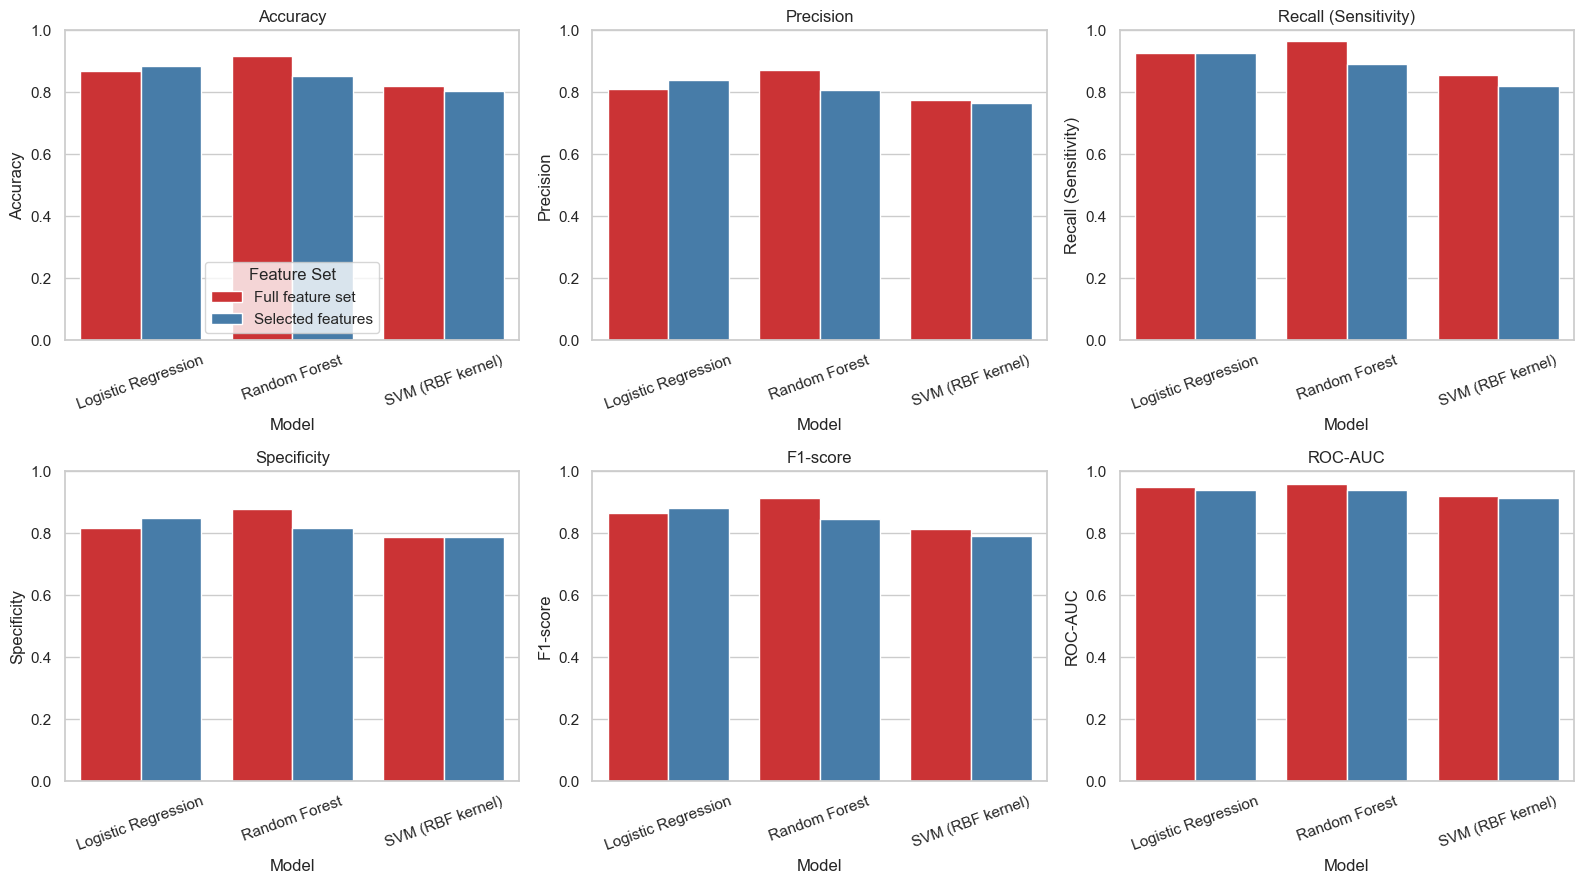

In [168]:
# Reshape for a grouped bar chart: one panel per metric
metrics_to_plot = ["Accuracy", "Precision", "Recall (Sensitivity)", "Specificity", "F1-score", "ROC-AUC"]
plot_df = pd.concat([pd.DataFrame(baseline_results), pd.DataFrame(selected_results)], ignore_index=True)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, metric in enumerate(metrics_to_plot):
    sns.barplot(data=plot_df, x="Model", y=metric, hue="Feature Set", ax=axes[i], palette="Set1")
    axes[i].set_title(metric)
    axes[i].set_ylim(0, 1)
    axes[i].tick_params(axis="x", rotation=20)
    if i != 0:
        axes[i].legend_.remove() if axes[i].get_legend() else None

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "10_full_vs_selected_all_metrics.png"))
plt.show()


In [170]:
# Percentage-point change in each metric (Selected - Full) per model
delta_records = []
for model_name in baseline_results_df.index:
    row = {"Model": model_name}
    for metric in metrics_to_plot:
        full_val = baseline_results_df.loc[model_name, metric]
        sel_val = selected_results_df.loc[model_name, metric]
        row[f"Delta {metric}"] = round(sel_val - full_val, 4)
    delta_records.append(row)

delta_df = pd.DataFrame(delta_records).set_index("Model")
delta_df.to_csv(os.path.join(TAB_DIR, "table_metric_deltas_selected_minus_full.csv"))
print("Change in each metric when moving from the full feature set to the selected subset")
print("(positive = improvement after feature selection):\n")
delta_df


Change in each metric when moving from the full feature set to the selected subset
(positive = improvement after feature selection):



,Delta Accuracy,Delta Precision,Delta Recall (Sensitivity),Delta Specificity,Delta F1-score,Delta ROC-AUC
Model,,,,,,
Logistic Regression,0.0164,0.0262,0.0000,0.0303,0.0147,-0.0097
Random Forest,-0.0656,-0.0645,-0.0714,-0.0606,-0.0678,-0.0184
SVM (RBF kernel),-0.0164,-0.0075,-0.0357,0.0000,-0.0205,-0.0049


## 11. Detailed evaluation: confusion matrices and ROC curves


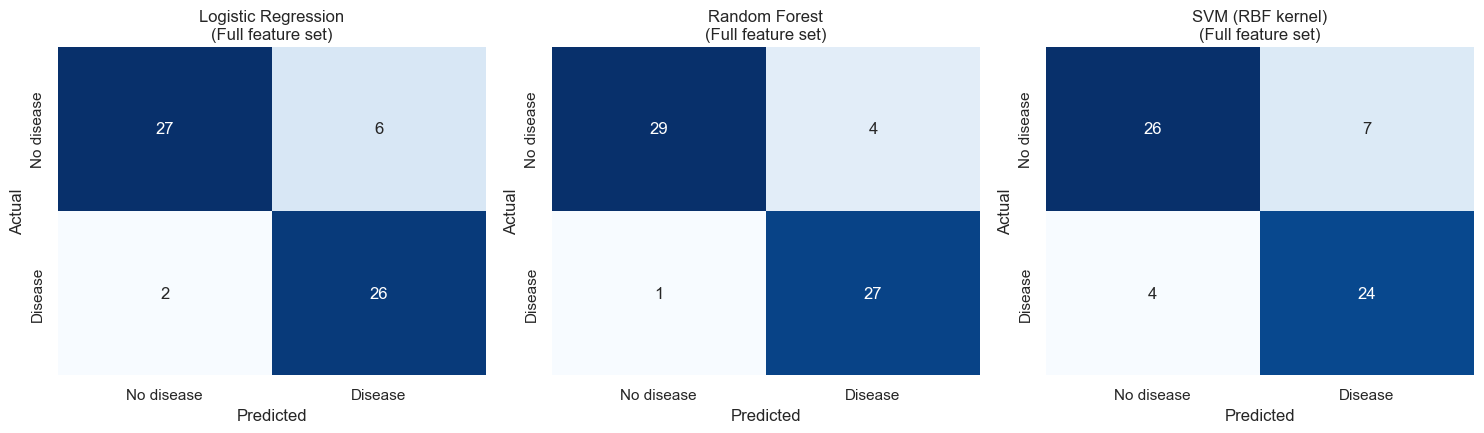

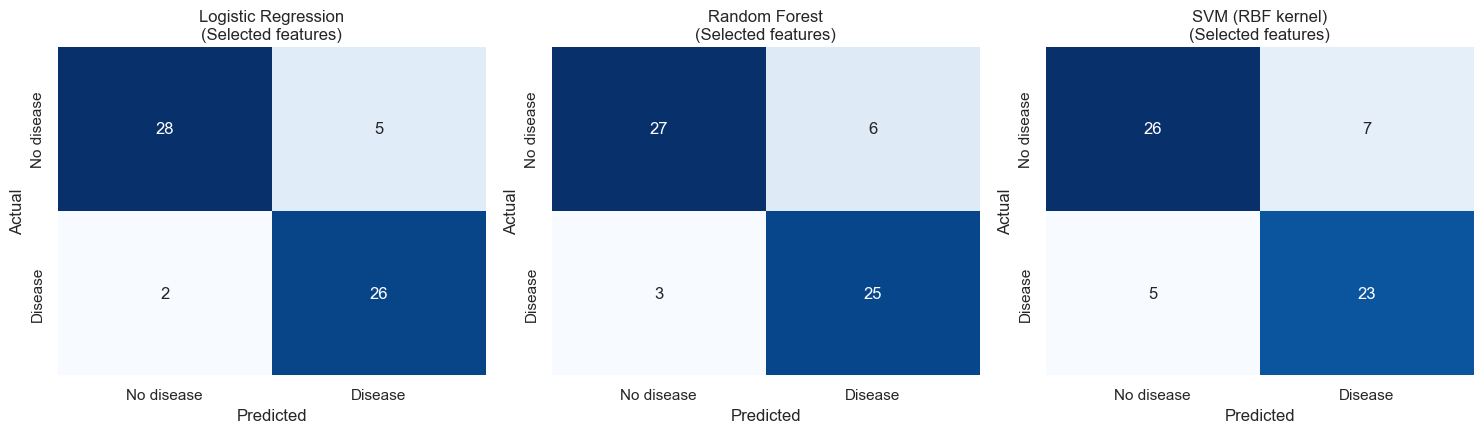

In [172]:
def plot_confusion_matrices(preds_dict, y_true, title_suffix, filename):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    for ax, (name, (y_pred, _)) in zip(axes, preds_dict.items()):
        cm = confusion_matrix(y_true, y_pred)
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                    xticklabels=["No disease", "Disease"], yticklabels=["No disease", "Disease"])
        ax.set_title(f"{name}\n{title_suffix}")
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, filename))
    plt.show()

plot_confusion_matrices(baseline_preds, y_test, "(Full feature set)", "11_confusion_matrices_full.png")
plot_confusion_matrices(selected_preds, y_test, "(Selected features)", "12_confusion_matrices_selected.png")


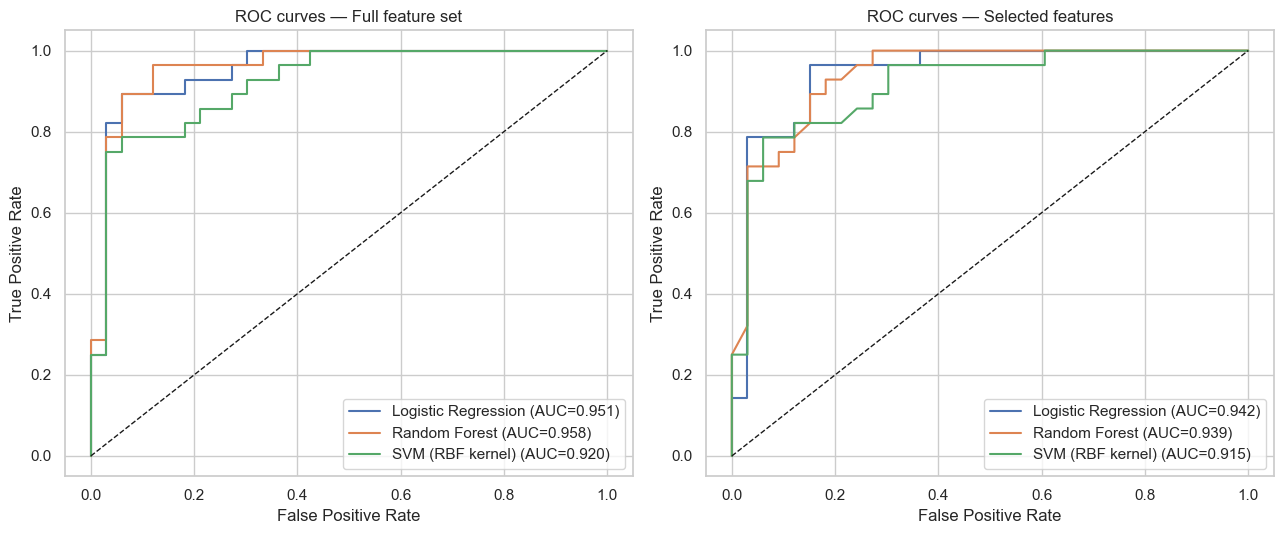

In [174]:
def plot_roc_curves(preds_full, preds_selected, y_true, filename):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

    for name, (_, y_proba) in preds_full.items():
        fpr, tpr, _ = roc_curve(y_true, y_proba)
        auc_val = roc_auc_score(y_true, y_proba)
        axes[0].plot(fpr, tpr, label=f"{name} (AUC={auc_val:.3f})")
    axes[0].plot([0, 1], [0, 1], "k--", linewidth=1)
    axes[0].set_title("ROC curves — Full feature set")
    axes[0].set_xlabel("False Positive Rate")
    axes[0].set_ylabel("True Positive Rate")
    axes[0].legend(loc="lower right")

    for name, (_, y_proba) in preds_selected.items():
        fpr, tpr, _ = roc_curve(y_true, y_proba)
        auc_val = roc_auc_score(y_true, y_proba)
        axes[1].plot(fpr, tpr, label=f"{name} (AUC={auc_val:.3f})")
    axes[1].plot([0, 1], [0, 1], "k--", linewidth=1)
    axes[1].set_title("ROC curves — Selected features")
    axes[1].set_xlabel("False Positive Rate")
    axes[1].set_ylabel("True Positive Rate")
    axes[1].legend(loc="lower right")

    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, filename))
    plt.show()

plot_roc_curves(baseline_preds, selected_preds, y_test, "13_roc_curves_comparison.png")


### Full `classification_report` for every model/feature-set combination (precision, recall, F1 per class)

In [176]:
for feature_set_name, preds_dict in [("Full feature set", baseline_preds), ("Selected features", selected_preds)]:
    print("=" * 70)
    print(feature_set_name)
    print("=" * 70)
    for name, (y_pred, _) in preds_dict.items():
        print(f"\n--- {name} ---")
        print(classification_report(y_test, y_pred, target_names=["No disease", "Disease"], digits=3))


Full feature set

--- Logistic Regression ---
              precision    recall  f1-score   support

  No disease      0.931     0.818     0.871        33
     Disease      0.812     0.929     0.867        28

    accuracy                          0.869        61
   macro avg      0.872     0.873     0.869        61
weighted avg      0.877     0.869     0.869        61


--- Random Forest ---
              precision    recall  f1-score   support

  No disease      0.967     0.879     0.921        33
     Disease      0.871     0.964     0.915        28

    accuracy                          0.918        61
   macro avg      0.919     0.922     0.918        61
weighted avg      0.923     0.918     0.918        61


--- SVM (RBF kernel) ---
              precision    recall  f1-score   support

  No disease      0.867     0.788     0.825        33
     Disease      0.774     0.857     0.814        28

    accuracy                          0.820        61
   macro avg      0.820     0.823

## 12. Summary of saved outputs


In [178]:
print("Figures saved to:", os.path.abspath(FIG_DIR))
for f in sorted(os.listdir(FIG_DIR)):
    print("  -", f)

print("\nTables saved to:", os.path.abspath(TAB_DIR))
for f in sorted(os.listdir(TAB_DIR)):
    print("  -", f)


Figures saved to: C:\Users\DELL\outputs\figures
  - 01_class_distribution.png
  - 02_continuous_distributions.png
  - 03_categorical_distributions.png
  - 04_boxplots_continuous.png
  - 05_correlation_heatmap.png
  - 06_target_correlation_ranked.png
  - 07_filter_method_scores.png
  - 08_rf_feature_importance.png
  - 09_rfecv_curve.png
  - 10_full_vs_selected_all_metrics.png
  - 11_confusion_matrices_full.png
  - 12_confusion_matrices_selected.png
  - 13_roc_curves_comparison.png

Tables saved to: C:\Users\DELL\outputs\tables
  - table_anova_f_scores.csv
  - table_correlation_matrix.csv
  - table_descriptive_stats_by_class.csv
  - table_feature_selection_triangulation.csv
  - table_full_vs_selected_comparison.csv
  - table_metric_deltas_selected_minus_full.csv
  - table_mutual_information.csv
  - table_rf_feature_importance.csv


## 13. Exporting consolidated results

A single consolidated results file (Excel workbook, one sheet per table) is produced so all key
numbers are available in one place rather than across multiple CSV files.


In [180]:
summary_path = os.path.join(OUT_DIR, "results_summary.xlsx")

with pd.ExcelWriter(summary_path, engine="openpyxl") as writer:
    all_results_df.reset_index().to_excel(writer, sheet_name="Full_vs_Selected_Metrics", index=False)
    delta_df.reset_index().to_excel(writer, sheet_name="Metric_Deltas", index=False)
    anova_df.to_excel(writer, sheet_name="ANOVA_F_Test", index=False)
    mi_df.to_excel(writer, sheet_name="Mutual_Information", index=False)
    rf_importance_df.to_excel(writer, sheet_name="RF_Feature_Importance", index=False)
    comparison_df.to_excel(writer, sheet_name="Feature_Selection_Triangulation", index=False)
    desc_by_class.to_excel(writer, sheet_name="Descriptive_Stats_By_Class")
    corr_matrix.to_excel(writer, sheet_name="Correlation_Matrix")

print("Consolidated results workbook written to:", os.path.abspath(summary_path))


Consolidated results workbook written to: C:\Users\DELL\outputs\results_summary.xlsx


## 14. Summary of key findings

This section prints a short, data-driven summary of the results computed above, pulling the key
numbers together in one place:

- Whether feature selection improved or reduced classification performance for each model
- Which features were most consistently identified as important across all four selection methods
- Which model performed best on the full feature set versus the selected subset


In [182]:
print("=" * 78)
print("SUMMARY OF KEY RESULTS")
print("=" * 78)

n_full = len(FEATURE_COLS)
n_sel = len(SELECTED_FEATURES)
print(f"\n1) DIMENSIONALITY REDUCTION\n"
      f"   Feature selection (RFECV, wrapped around Logistic Regression) reduced the feature\n"
      f"   space from {n_full} to {n_sel} features ({(1 - n_sel/n_full)*100:.1f}% reduction),\n"
      f"   retaining: {SELECTED_FEATURES}\n")

print("2) PERFORMANCE IMPACT PER MODEL (Selected - Full, in percentage points):")
for model_name in delta_df.index:
    acc_delta = delta_df.loc[model_name, "Delta Accuracy"] * 100
    auc_delta = delta_df.loc[model_name, "Delta ROC-AUC"] * 100
    direction_acc = "improved" if acc_delta > 0 else ("stayed the same" if acc_delta == 0 else "declined")
    print(f"   - {model_name}: Accuracy {direction_acc} by {acc_delta:+.2f} pp; "
          f"ROC-AUC changed by {auc_delta:+.2f} pp")

best_full_model = baseline_results_df["Accuracy"].idxmax()
best_selected_model = selected_results_df["Accuracy"].idxmax()
print(f"\n3) BEST-PERFORMING MODEL\n"
      f"   Full feature set   -> {best_full_model} "
      f"(Accuracy={baseline_results_df.loc[best_full_model, 'Accuracy']:.3f}, "
      f"ROC-AUC={baseline_results_df.loc[best_full_model, 'ROC-AUC']:.3f})\n"
      f"   Selected features  -> {best_selected_model} "
      f"(Accuracy={selected_results_df.loc[best_selected_model, 'Accuracy']:.3f}, "
      f"ROC-AUC={selected_results_df.loc[best_selected_model, 'ROC-AUC']:.3f})\n")

top_agreement = comparison_df.sort_values("Agreement count", ascending=False).head(5)
print("4) FEATURE IMPORTANCE CONSENSUS (top 5 features by cross-method agreement):")
for _, row in top_agreement.iterrows():
    print(f"   - {row['Feature']}: agreed upon by {row['Agreement count']}/4 methods")

print("\n" + "=" * 78)


SUMMARY OF KEY RESULTS

1) DIMENSIONALITY REDUCTION
   Feature selection (RFECV, wrapped around Logistic Regression) reduced the feature
   space from 13 to 9 features (30.8% reduction),
   retaining: ['sex', 'cp', 'trestbps', 'fbs', 'thalach', 'exang', 'slope', 'ca', 'thal']

2) PERFORMANCE IMPACT PER MODEL (Selected - Full, in percentage points):
   - Logistic Regression: Accuracy improved by +1.64 pp; ROC-AUC changed by -0.97 pp
   - Random Forest: Accuracy declined by -6.56 pp; ROC-AUC changed by -1.84 pp
   - SVM (RBF kernel): Accuracy declined by -1.64 pp; ROC-AUC changed by -0.49 pp

3) BEST-PERFORMING MODEL
   Full feature set   -> Random Forest (Accuracy=0.918, ROC-AUC=0.958)
   Selected features  -> Logistic Regression (Accuracy=0.885, ROC-AUC=0.942)

4) FEATURE IMPORTANCE CONSENSUS (top 5 features by cross-method agreement):
   - cp: agreed upon by 4/4 methods
   - thalach: agreed upon by 4/4 methods
   - exang: agreed upon by 4/4 methods
   - ca: agreed upon by 4/4 methods
